# OASIS TASK 4
## Unveiling the Android App Market
### Google Play Store Analysis

This notebook performs a comprehensive data analysis of the Google Play Store dataset to uncover insights for developers planning to launch new Android apps. It covers data loading, cleaning, exploratory data analysis, and sentiment analysis.

## 1. Setup and Libraries

In [34]:
# Install necessary libraries
!pip -q install vaderSentiment

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import kagglehub
import os
import warnings
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Set visualization styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

## 2. Download and Load the Datasets

In [35]:
!pip -q install kagglehub

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("lava18/google-play-store-apps")

apps = pd.read_csv(os.path.join(path, "googleplaystore.csv"))
reviews = pd.read_csv(os.path.join(path, "googleplaystore_user_reviews.csv"))

print("Apps:", apps.shape)
print("Reviews:", reviews.shape)

100%|██████████| 1.94M/1.94M [00:00<00:00, 119MB/s]

Extracting files...


Apps: (10841, 13)
Reviews: (64295, 5)


In [36]:
# Display dataset path and filenames
print(f"Dataset downloaded to: {path}")
print(f"Apps dataset file: {os.path.join(path, 'googleplaystore.csv')}")
print(f"Reviews dataset file: {os.path.join(path, 'googleplaystore_user_reviews.csv')}")

print("\n--- Apps Dataset Info ---")
print("Shape:", apps.shape)
print("Columns:", apps.columns.tolist())
print("First 5 rows:\n", apps.head())
print("Data types:\n", apps.info())
print("Missing values:\n", apps.isnull().sum())

print("\n--- Reviews Dataset Info ---")
print("Shape:", reviews.shape)
print("Columns:", reviews.columns.tolist())
print("First 5 rows:\n", reviews.head())
print("Data types:\n", reviews.info())
print("Missing values:\n", reviews.isnull().sum())

Dataset downloaded to: /root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6
Apps dataset file: /root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6/googleplaystore.csv
Reviews dataset file: /root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6/googleplaystore_user_reviews.csv

--- Apps Dataset Info ---
Shape: (10841, 13)
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
First 5 rows:
                                                  App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Col

## 3. Data Cleaning

Real-world datasets often contain inconsistencies, missing values, and incorrect data types. This section focuses on cleaning both the `apps` and `reviews` datasets to prepare them for analysis. We will handle duplicates, missing values, and convert data types to ensure data integrity and usability.

### Apps Dataset Cleaning

We will address duplicate entries, convert various columns (Rating, Reviews, Installs, Price, Size) to appropriate numeric formats, and handle missing values, especially for ratings. For missing ratings, we will impute with the median rating *per category* where possible, as this maintains some categorical context rather than a global arbitrary replacement. This approach assumes that apps within the same category might have similar rating distributions.

In [37]:
print("Apps dataset shape before cleaning:", apps.shape)

# 1. Handle Duplicate Rows
apps.drop_duplicates(inplace=True)
print(f"Apps dataset shape after dropping duplicates: {apps.shape}")

# 2. Handle Invalid Category Value (Row 10472 has '1.9' as category)
# This row seems to be misaligned, with '1.9' in Category, '4.1' in Rating, etc.
# A common approach is to drop such clearly malformed rows or try to fix them if patterns are obvious.
# Given the extent of misalignment, dropping it is safer.
apps = apps[apps['Category'] != '1.9']
print(f"Apps dataset shape after removing malformed '1.9' category row: {apps.shape}")

# 3. Convert 'Reviews' to numeric
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

# 4. Convert 'Installs' to numeric
def clean_installs(installs_str):
    if isinstance(installs_str, str):
        return int(installs_str.replace('+', '').replace(',', ''))
    return installs_str
apps['Installs'] = apps['Installs'].apply(clean_installs)

# 5. Convert 'Price' to numeric
def clean_price(price_str):
    if isinstance(price_str, str):
        return float(price_str.replace('$', ''))
    return price_str
apps['Price'] = apps['Price'].apply(clean_price)

# 6. Convert 'Size' to numeric (in MB)
def clean_size(size_str):
    if isinstance(size_str, str):
        if 'M' in size_str:
            return float(size_str.replace('M', ''))
        elif 'k' in size_str:
            return float(size_str.replace('k', '')) / 1024  # Convert KB to MB
        elif 'Varies with device' in size_str:
            return np.nan # Treat 'Varies with device' as missing for now
    return size_str

apps['Size'] = apps['Size'].apply(clean_size)

# 7. Convert 'Last Updated' to datetime
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'], errors='coerce')

# 8. Clean 'Content Rating' by removing '+'
apps['Content Rating'] = apps['Content Rating'].str.replace('+', '', regex=False)

# 9. Handle Missing 'Rating' values
# We will fill missing ratings with the median rating of their respective category.
# This is a more robust imputation than filling with a global mean/median.
apps['Rating'] = apps.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))

# For any remaining NaNs in 'Rating' (categories with all NaNs), fill with the overall median rating
apps['Rating'].fillna(apps['Rating'].median(), inplace=True)

# Drop rows where critical numeric columns might still be NaN after cleaning
# (e.g., if Installs/Reviews somehow became NaN due to unhandled non-string values originally)
apps.dropna(subset=['Rating', 'Reviews', 'Installs', 'Price'], inplace=True)

# Create the clean apps dataframe
apps_clean = apps.copy()

print("\nApps dataset info after cleaning:")
print(apps_clean.info())
print("Missing values after cleaning:\n", apps_clean.isnull().sum())
print("Apps dataset shape after cleaning:", apps_clean.shape)

# Create apps_analysis by handling duplicate App names, keeping the one with the most reviews
apps_analysis = (
    apps_clean
    .sort_values('Reviews', ascending=False)
    .drop_duplicates(subset='App', keep='first')
    .copy()
)

print(f"\n--- Validation after creating apps_analysis ---")
print(f"Unique apps in apps_analysis: {apps_analysis['App'].nunique()}")
print(f"Number of rows in apps_analysis: {apps_analysis.shape[0]}")
print(f"Duplicate app names in apps_analysis: {apps_analysis['App'].duplicated().sum()}")

Apps dataset shape before cleaning: (10841, 13)
Apps dataset shape after dropping duplicates: (10358, 13)
Apps dataset shape after removing malformed '1.9' category row: (10357, 13)

Apps dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10357 non-null  object        
 1   Category        10357 non-null  object        
 2   Rating          10357 non-null  float64       
 3   Reviews         10357 non-null  int64         
 4   Size            8831 non-null   float64       
 5   Installs        10357 non-null  int64         
 6   Type            10356 non-null  object        
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  object        
 9   Genres          10357 non-null  object        
 10  Last Updated    10357 non-null  datetime64[ns]
 11

### Reviews Dataset Cleaning

For the reviews dataset, the primary cleaning involves handling duplicate reviews and missing `Translated_Review` entries. Since VADER sentiment analysis requires text, we will drop rows where `Translated_Review` is missing, as these cannot contribute to sentiment analysis.

In [38]:
print("Reviews dataset shape before cleaning:", reviews.shape)

# 1. Handle Duplicate Reviews
reviews.drop_duplicates(inplace=True)
print(f"Reviews dataset shape after dropping duplicates: {reviews.shape}")

# 2. Handle Missing 'Translated_Review'
# Drop rows where 'Translated_Review' is NaN, as we need this for sentiment analysis.
reviews.dropna(subset=['Translated_Review'], inplace=True)

# Create the clean reviews dataframe
reviews_clean = reviews.copy()

print("\nReviews dataset info after cleaning:")
print(reviews_clean.info())
print("Missing values after cleaning:\n", reviews_clean.isnull().sum())
print("Reviews dataset shape after cleaning:", reviews_clean.shape)

Reviews dataset shape before cleaning: (64295, 5)
Reviews dataset shape after dropping duplicates: (30679, 5)

Reviews dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 29692 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29692 non-null  object 
 1   Translated_Review       29692 non-null  object 
 2   Sentiment               29692 non-null  object 
 3   Sentiment_Polarity      29692 non-null  float64
 4   Sentiment_Subjectivity  29692 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.4+ MB
None
Missing values after cleaning:
 App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64
Reviews dataset shape after cleaning: (29692, 5)


## 4. Exploratory Data Analysis

With the datasets cleaned, we can now proceed with Exploratory Data Analysis (EDA) to understand the main characteristics of the data. This section will provide descriptive statistics and initial insights into the Google Play Store market.

### General Statistics of Apps

In [39]:
# Number of apps
num_apps = apps_analysis['App'].nunique()
print(f"Total Number of Unique Apps: {num_apps}")

# Number of categories
num_categories = apps_analysis['Category'].nunique()
print(f"Total Number of Categories: {num_categories}")

# Average rating
avg_rating = apps_analysis['Rating'].mean()
print(f"Overall Average Rating: {avg_rating:.2f}")

# Total installs (sum of 'Installs' column)
total_installs = apps_analysis['Installs'].sum()
print(f"Total Estimated Installs Across All Apps: {total_installs:,}")

# Free vs Paid apps
free_paid_counts = apps_analysis['Type'].value_counts()
free_paid_percentage = apps_analysis['Type'].value_counts(normalize=True) * 100
print("\nDistribution of Free vs. Paid Apps:")
print(free_paid_counts)
print("\nPercentage Distribution of Free vs. Paid Apps:")
print(free_paid_percentage)

# Average price for paid apps
paid_apps = apps_analysis[apps_analysis['Type'] == 'Paid']
if not paid_apps.empty:
    avg_price = paid_apps['Price'].mean()
    print(f"\nAverage Price for Paid Apps: ${avg_price:.2f}")
else:
    print("\nNo Paid Apps found in the dataset.")

# Most reviewed apps
most_reviewed_apps = apps_analysis[['App', 'Reviews']].sort_values(by='Reviews', ascending=False).head(10)
print("\nTop 10 Most Reviewed Apps:")
print(most_reviewed_apps)

Total Number of Unique Apps: 9659
Total Number of Categories: 33
Overall Average Rating: 4.19
Total Estimated Installs Across All Apps: 75,322,526,427

Distribution of Free vs. Paid Apps:
Type
Free    8904
Paid     754
Name: count, dtype: int64

Percentage Distribution of Free vs. Paid Apps:
Type
Free    92.193001
Paid     7.806999
Name: proportion, dtype: float64

Average Price for Paid Apps: $14.06

Top 10 Most Reviewed Apps:
                                                    App   Reviews
2544                                           Facebook  78158306
336                                  WhatsApp Messenger  69119316
2604                                          Instagram  66577446
382            Messenger – Text and Video Chat for Free  56646578
1879                                     Clash of Clans  44893888
4005            Clean Master- Space Cleaner & Antivirus  42916526
1872                                     Subway Surfers  27725352
3665                                    

## 5. Category Analysis — App Market Saturation

Understanding the distribution of apps across different categories is crucial for a developer. A category with many apps indicates high market saturation and potentially fierce competition, while a category with fewer apps might suggest a niche market or less competition. This section analyzes the number of apps per category.

Number of Apps by Category (Top 10):
Category
FAMILY             1875
GAME                946
TOOLS               829
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64

Number of Apps by Category (Least 10):
Category
ENTERTAINMENT         86
AUTO_AND_VEHICLES     85
LIBRARIES_AND_DEMO    84
WEATHER               79
HOUSE_AND_HOME        73
EVENTS                64
ART_AND_DESIGN        61
PARENTING             60
COMICS                56
BEAUTY                53
Name: count, dtype: int64


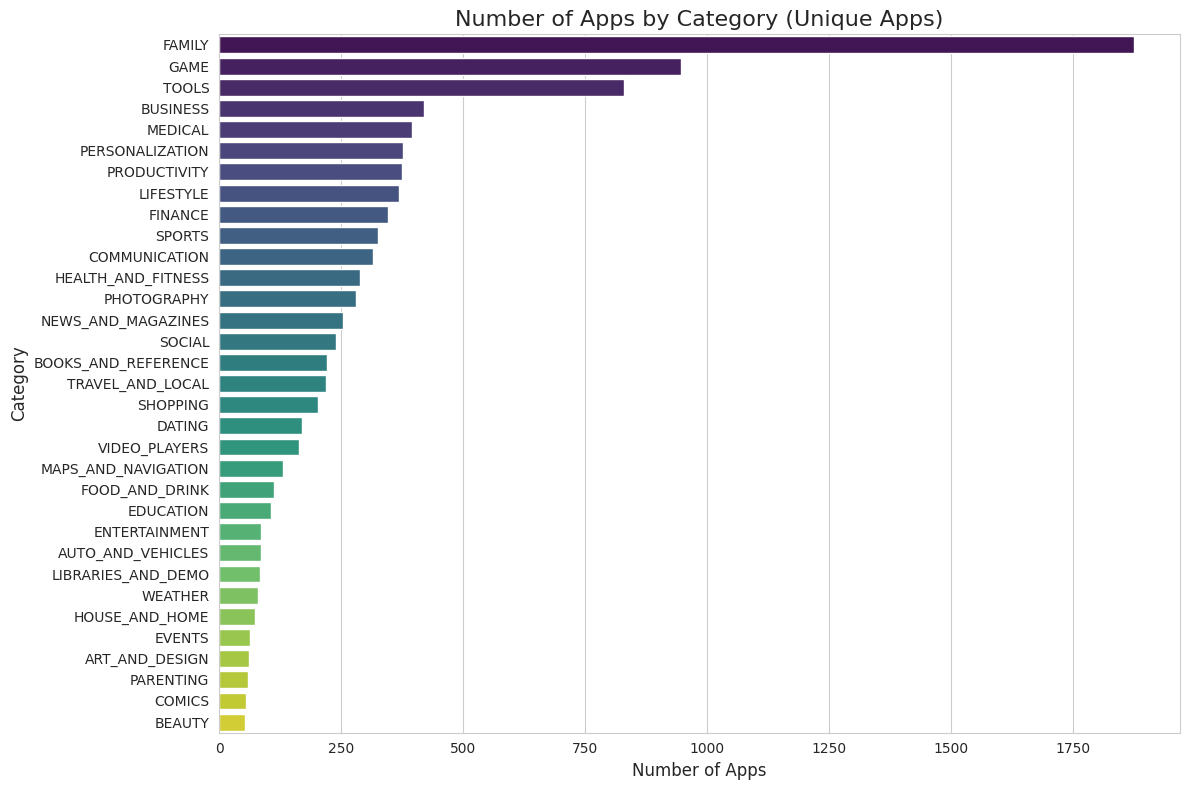


Top 10 Most Saturated Categories (based on unique apps):
- FAMILY: 1875 apps
- GAME: 946 apps
- TOOLS: 829 apps
- BUSINESS: 420 apps
- MEDICAL: 395 apps
- PERSONALIZATION: 376 apps
- PRODUCTIVITY: 374 apps
- LIFESTYLE: 369 apps
- FINANCE: 345 apps
- SPORTS: 325 apps

Least Saturated Categories (based on unique apps):
- ENTERTAINMENT: 86 apps
- AUTO_AND_VEHICLES: 85 apps
- LIBRARIES_AND_DEMO: 84 apps
- WEATHER: 79 apps
- HOUSE_AND_HOME: 73 apps
- EVENTS: 64 apps
- ART_AND_DESIGN: 61 apps
- PARENTING: 60 apps
- COMICS: 56 apps
- BEAUTY: 53 apps

Interpretation of Market Saturation for a Developer:
Market saturation refers to the extent to which a market is supplied with a product or service. For app developers:
1. High Saturation: Categories like 'FAMILY', 'GAME', and 'TOOLS' have a very large number of unique apps. Launching a new app here means facing intense competition for visibility, downloads, and user attention. It requires a highly differentiated product, significant marketing e

In [40]:
# Calculate the number of apps in every category using apps_analysis
category_counts = apps_analysis['Category'].value_counts().sort_values(ascending=False)

print("Number of Apps by Category (Top 10):")
print(category_counts.head(10))
print("\nNumber of Apps by Category (Least 10):")
print(category_counts.tail(10))

# Create a professional horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Number of Apps by Category (Unique Apps)', fontsize=16)
plt.xlabel('Number of Apps', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

# Identify and print top 10 most saturated categories
top_10_saturated = category_counts.head(10)
print("\nTop 10 Most Saturated Categories (based on unique apps):")
for category, count in top_10_saturated.items():
    print(f"- {category}: {count} apps")

# Identify and print least saturated categories
least_saturated = category_counts.tail(10)
print("\nLeast Saturated Categories (based on unique apps):")
for category, count in least_saturated.items():
    print(f"- {category}: {count} apps")

print("\nInterpretation of Market Saturation for a Developer:")
print("Market saturation refers to the extent to which a market is supplied with a product or service. For app developers:")
print("1. High Saturation: Categories like 'FAMILY', 'GAME', and 'TOOLS' have a very large number of unique apps. Launching a new app here means facing intense competition for visibility, downloads, and user attention. It requires a highly differentiated product, significant marketing efforts, and robust features to stand out.")
print("2. Low Saturation: Categories like 'BEAUTY', 'EVENTS', and 'PARENTING' have fewer unique apps. While this might suggest less direct competition, it could also indicate a smaller target audience or a less commercially viable niche. However, a well-executed app in these categories could capture a larger market share and become a dominant player with less effort than in highly saturated markets.")
print("Developers should weigh the potential for high rewards in large, saturated markets against the higher barriers to entry, or consider targeting less saturated niches where differentiation can be achieved more easily.")

## 6. Ratings Analysis

App ratings are a critical indicator of user satisfaction and app quality. This section explores the distribution of ratings across all apps and analyzes average ratings by category, providing insights into user preferences and expectations within different market segments.

### Overall Ratings Distribution

Overall Average App Rating: 4.19
Overall Median App Rating: 4.30


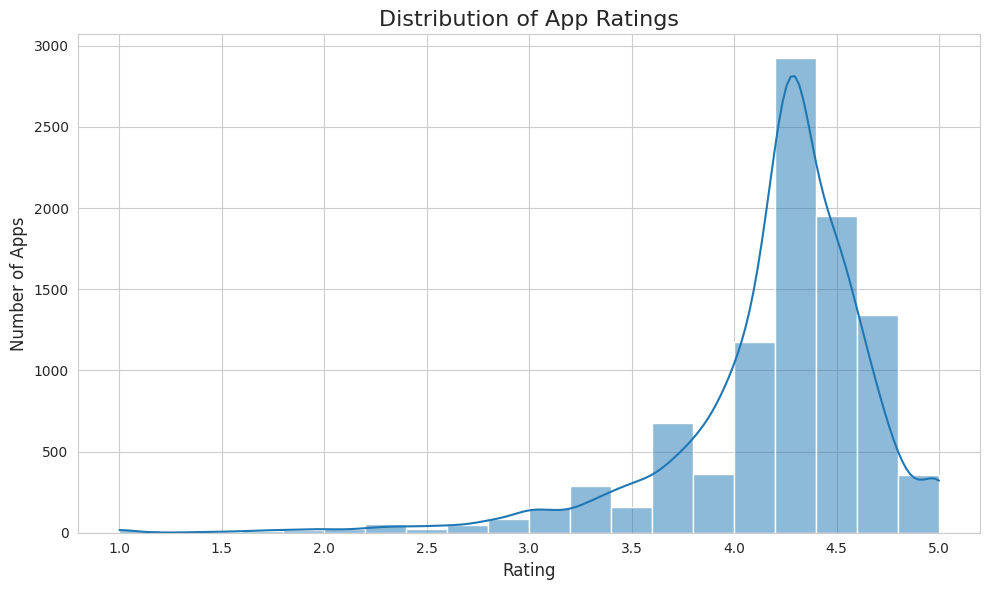

In [41]:
# Overall average and median rating
overall_avg_rating = apps_analysis['Rating'].mean()
overall_median_rating = apps_analysis['Rating'].median()

print(f"Overall Average App Rating: {overall_avg_rating:.2f}")
print(f"Overall Median App Rating: {overall_median_rating:.2f}")

# 1. Histogram of ratings
plt.figure(figsize=(10, 6))
sns.histplot(apps_analysis['Rating'], kde=True, bins=20, palette='coolwarm')
plt.title('Distribution of App Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.tight_layout()
plt.show()

### Average Rating by Category

To avoid misleading conclusions from categories with very few apps, we will set a minimum threshold for the number of apps a category must have to be included in the average rating calculation. This ensures that the average ratings are representative.


Average Rating by Category (for categories with at least 50 apps, Top 10):
Category
EVENTS                 4.454688
BOOKS_AND_REFERENCE    4.381982
ART_AND_DESIGN         4.360656
EDUCATION              4.355140
PERSONALIZATION        4.346277
PARENTING              4.316667
BEAUTY                 4.283019
HEALTH_AND_FITNESS     4.282292
SOCIAL                 4.255230
WEATHER                4.248101
Name: Rating, dtype: float64

Average Rating by Category (for categories with at least 50 apps, Bottom 10):
Category
HOUSE_AND_HOME         4.150685
FINANCE                4.138551
NEWS_AND_MAGAZINES     4.137008
ENTERTAINMENT          4.129070
LIFESTYLE              4.113008
TRAVEL_AND_LOCAL       4.088584
TOOLS                  4.061279
VIDEO_PLAYERS          4.059146
MAPS_AND_NAVIGATION    4.052672
DATING                 4.006471
Name: Rating, dtype: float64


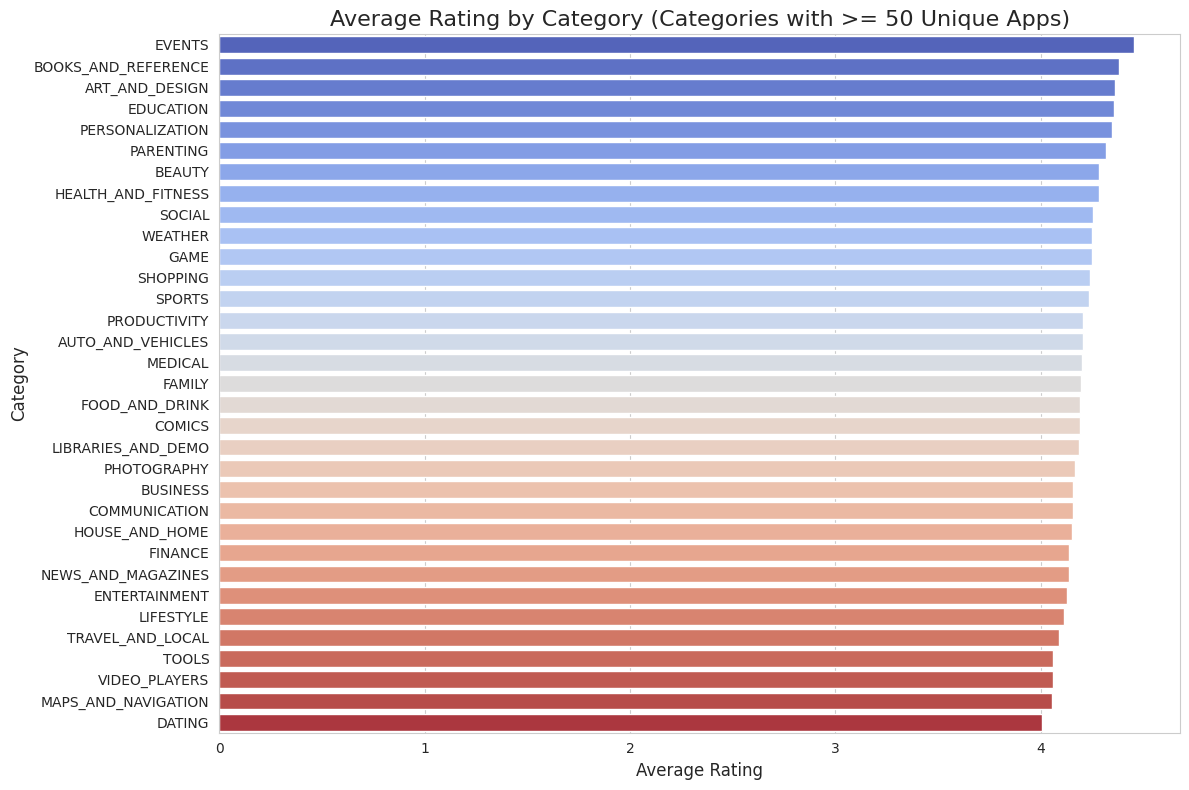


Highest-Rated Categories (Top 5):
- EVENTS: 4.45
- BOOKS_AND_REFERENCE: 4.38
- ART_AND_DESIGN: 4.36
- EDUCATION: 4.36
- PERSONALIZATION: 4.35

Lowest-Rated Categories (Bottom 5):
- TRAVEL_AND_LOCAL: 4.09
- TOOLS: 4.06
- VIDEO_PLAYERS: 4.06
- MAPS_AND_NAVIGATION: 4.05
- DATING: 4.01

Explanation for minimum app threshold:
Using a minimum number of apps per category (e.g., 50 apps) helps to ensure that the calculated average ratings are statistically more robust and less susceptible to skew from categories with very few apps. A category with only one or two apps might show a perfect 5.0 rating, but this would not be a reliable indicator of user satisfaction across a broader user base. This threshold helps us focus on categories with a more established market presence and user feedback.


In [42]:
# Calculate average rating by category
# Set a minimum number of apps per category to consider for meaningful average rating
min_apps_per_category = 50 # Example threshold, can be adjusted

category_app_counts = apps_analysis['Category'].value_counts()
filtered_categories = category_app_counts[category_app_counts >= min_apps_per_category].index

# Filter apps_analysis to include only categories above the threshold
apps_filtered_for_rating = apps_analysis[apps_analysis['Category'].isin(filtered_categories)]

avg_rating_by_category = apps_filtered_for_rating.groupby('Category')['Rating'].mean().sort_values(ascending=False)

print(f"\nAverage Rating by Category (for categories with at least {min_apps_per_category} apps, Top 10):")
print(avg_rating_by_category.head(10))

print(f"\nAverage Rating by Category (for categories with at least {min_apps_per_category} apps, Bottom 10):")
print(avg_rating_by_category.tail(10))

# Create a professional chart: Average Rating by Category
plt.figure(figsize=(12, 8))
sns.barplot(x=avg_rating_by_category.values, y=avg_rating_by_category.index, palette='coolwarm')
plt.title(f'Average Rating by Category (Categories with >= {min_apps_per_category} Unique Apps)', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

# Identify highest-rated categories
highest_rated_categories = avg_rating_by_category.head(5)
print("\nHighest-Rated Categories (Top 5):")
for category, rating in highest_rated_categories.items():
    print(f"- {category}: {rating:.2f}")

# Identify lowest-rated categories
lowest_rated_categories = avg_rating_by_category.tail(5)
print("\nLowest-Rated Categories (Bottom 5):")
for category, rating in lowest_rated_categories.items():
    print(f"- {category}: {rating:.2f}")

print("\nExplanation for minimum app threshold:")
print("Using a minimum number of apps per category (e.g., 50 apps) helps to ensure that the calculated average ratings are statistically more robust and less susceptible to skew from categories with very few apps. A category with only one or two apps might show a perfect 5.0 rating, but this would not be a reliable indicator of user satisfaction across a broader user base. This threshold helps us focus on categories with a more established market presence and user feedback.")

## 7. App Size vs Number of Installs

This section explores the relationship between an app's size and its popularity, as measured by the number of installs. Larger apps might offer more features but could also deter users with limited storage or slower internet connections. We will visualize this relationship using a scatter plot and calculate correlation coefficients to quantify the association.

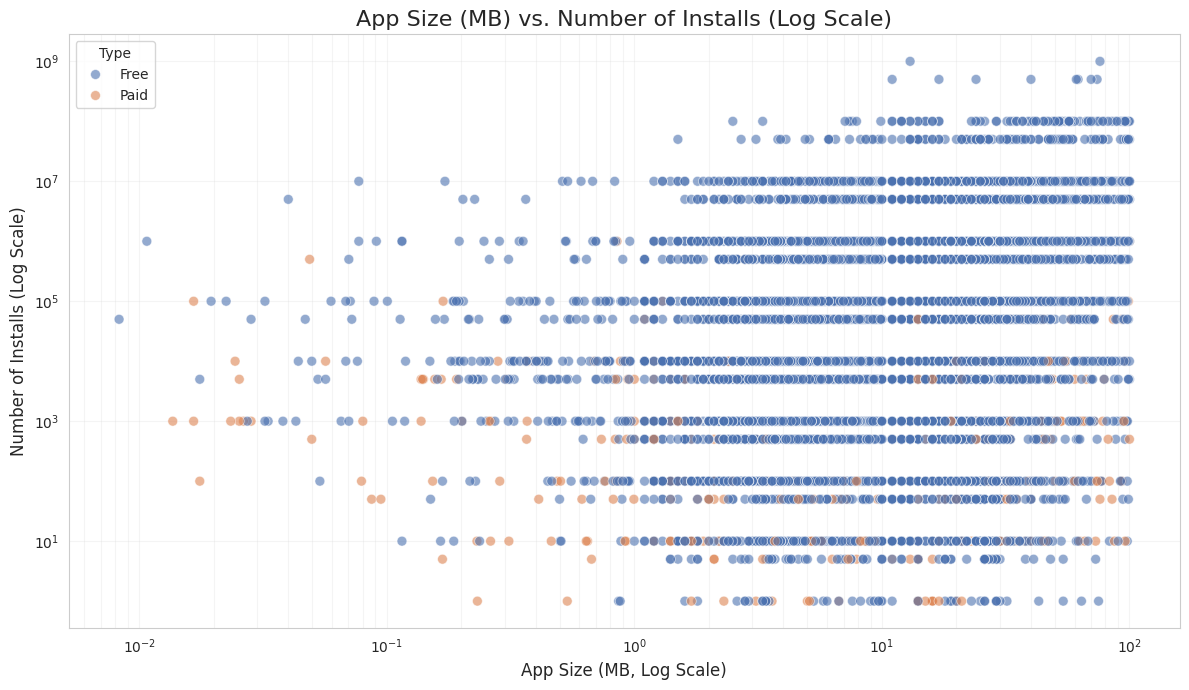

Pearson correlation between App Size and Number of Installs: 0.13
Pearson correlation between Log(App Size) and Log(Number of Installs): 0.28

Interpretation of correlation:
The scatter plot and correlation coefficients suggest the relationship between app size and installs. A Pearson correlation close to 0 indicates a weak or no linear relationship. A positive value indicates that as one variable increases, the other tends to increase, and a negative value means the opposite.
There appears to be a weak positive correlation between (log-transformed) app size and the number of installs. Larger apps might tend to have slightly more installs, but the relationship is not strong.

Important Note: Correlation does not imply causation. Even if a correlation exists, it does not mean that app size directly causes more or fewer installs. Other factors, such as app quality, marketing, features, and category, are likely to be significant contributors.


In [43]:
# Drop rows where 'Size' or 'Installs' might be NaN for this analysis (though 'Installs' should be clean)
size_installs_df = apps_analysis.dropna(subset=['Size', 'Installs']).copy()

# Ensure 'Installs' is numeric and handle potential zero values for log transform
size_installs_df['Installs_Log'] = size_installs_df['Installs'].apply(lambda x: np.log10(x) if x > 0 else 0)

# Create a scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Size', y='Installs', data=size_installs_df, alpha=0.6, s=50, hue='Type', palette='deep')
plt.xscale('log') # Use logarithmic scale for X-axis (Size) as it can be very skewed
plt.yscale('log') # Use logarithmic scale for Y-axis (Installs) as it is highly skewed
plt.title('App Size (MB) vs. Number of Installs (Log Scale)', fontsize=16)
plt.xlabel('App Size (MB, Log Scale)', fontsize=12)
plt.ylabel('Number of Installs (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

# Calculate Pearson correlation
pearson_corr = size_installs_df['Size'].corr(size_installs_df['Installs'])
print(f"Pearson correlation between App Size and Number of Installs: {pearson_corr:.2f}")

# Calculate Pearson correlation using log-transformed values
# Only consider installs > 0 for log transformation
size_installs_log_df = size_installs_df[size_installs_df['Installs'] > 0].copy()
size_installs_log_df['Size_Log'] = np.log10(size_installs_log_df['Size'])
size_installs_log_df['Installs_Log'] = np.log10(size_installs_log_df['Installs'])
log_pearson_corr = size_installs_log_df['Size_Log'].corr(size_installs_log_df['Installs_Log'])
print(f"Pearson correlation between Log(App Size) and Log(Number of Installs): {log_pearson_corr:.2f}")

print("\nInterpretation of correlation:")
print("The scatter plot and correlation coefficients suggest the relationship between app size and installs. A Pearson correlation close to 0 indicates a weak or no linear relationship. A positive value indicates that as one variable increases, the other tends to increase, and a negative value means the opposite.")

if abs(log_pearson_corr) < 0.2:
    print("There appears to be no meaningful linear correlation between (log-transformed) app size and the number of installs.")
elif log_pearson_corr > 0:
    if log_pearson_corr < 0.5:
        print("There appears to be a weak positive correlation between (log-transformed) app size and the number of installs. Larger apps might tend to have slightly more installs, but the relationship is not strong.")
    else:
        print("There appears to be a strong positive correlation between (log-transformed) app size and the number of installs. Larger apps tend to have significantly more installs.")
else:
    if abs(log_pearson_corr) < 0.5:
        print("There appears to be a weak negative correlation between (log-transformed) app size and the number of installs. Larger apps might tend to have slightly fewer installs, but the relationship is not strong.")
    else:
        print("There appears to be a strong negative correlation between (log-transformed) app size and the number of installs. Larger apps tend to have significantly fewer installs.")

print("\nImportant Note: Correlation does not imply causation. Even if a correlation exists, it does not mean that app size directly causes more or fewer installs. Other factors, such as app quality, marketing, features, and category, are likely to be significant contributors.")

## 8. Pricing Analysis

Pricing strategy is a crucial aspect for app developers. This section analyzes the distribution of free versus paid applications and then delves into the pricing characteristics of the paid apps, including their price distribution and key statistics.

### Free vs Paid Apps

Understanding the proportion of free versus paid apps gives insight into the dominant monetization models in the Play Store.

Number of Free vs. Paid Apps:
Type
Free    8904
Paid     754
Name: count, dtype: int64

Percentage of Free vs. Paid Apps:
Type
Free    92.19
Paid     7.81
Name: proportion, dtype: float64


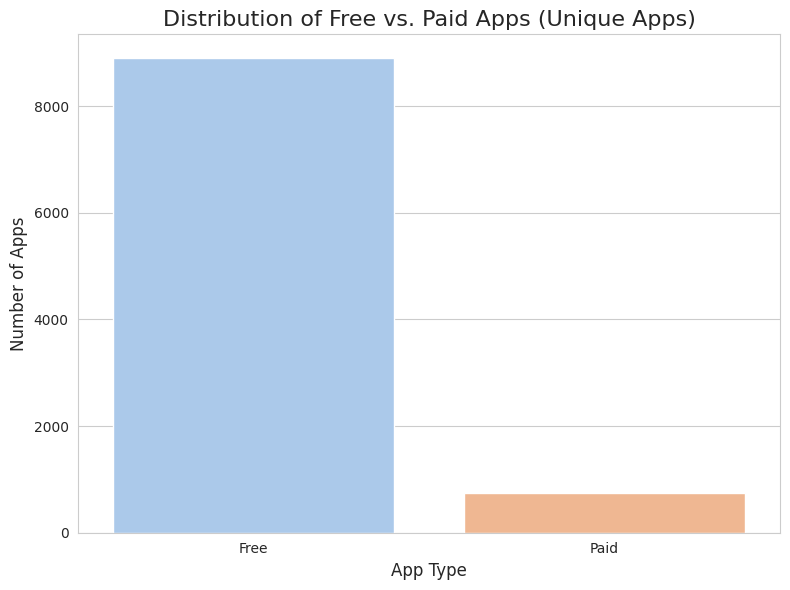

In [44]:
# Calculate number and percentage of free vs paid apps
free_paid_counts = apps_analysis['Type'].value_counts()
free_paid_percentage = apps_analysis['Type'].value_counts(normalize=True) * 100

print("Number of Free vs. Paid Apps:")
print(free_paid_counts)
print("\nPercentage of Free vs. Paid Apps:")
print(free_paid_percentage.round(2))

# Create a bar chart for Free vs Paid
plt.figure(figsize=(8, 6))
sns.barplot(x=free_paid_counts.index, y=free_paid_counts.values, palette='pastel')
plt.title('Distribution of Free vs. Paid Apps (Unique Apps)', fontsize=16)
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.tight_layout()
plt.show()

### Paid App Prices

For paid applications, we will examine the distribution of their prices, summary statistics, and identify the most expensive apps. We will also consider how to visualize this data effectively given potential outliers.

Summary Statistics for Paid App Prices:
count    754.000000
mean      14.055902
std       58.821000
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64

Median Price for Paid Apps: $2.99
Average Price for Paid Apps: $14.06


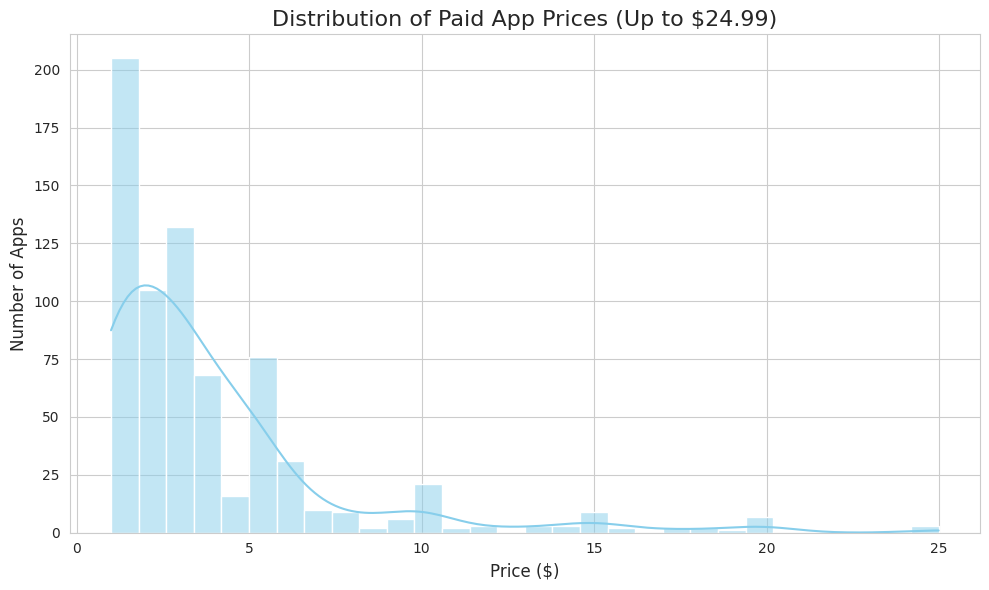


Note: The price distribution histogram is capped at $24.99 (approximately the 95th percentile) to provide a clearer view of the majority of prices, as extreme outliers would otherwise compress the scale and make the distribution unreadable.

Top 10 Most Expensive Apps:
                                    App   Price
4367           I'm Rich - Trump Edition  400.00
4197             most expensive app (H)  399.99
5356                  I Am Rich Premium  399.99
5369                          I am Rich  399.99
5364     I am rich (Most expensive app)  399.99
5351                          I am rich  399.99
5358                         I am Rich!  399.99
5362                      I Am Rich Pro  399.99
5373                 I AM RICH PRO PLUS  399.99
9934  I'm Rich/Eu sou Rico/أنا غني/我很有錢  399.99


In [45]:
# Filter for paid applications
paid_apps_df = apps_analysis[apps_analysis['Type'] == 'Paid'].copy()

if not paid_apps_df.empty:
    # Summary statistics for paid app prices
    print("Summary Statistics for Paid App Prices:")
    print(paid_apps_df['Price'].describe())

    print(f"\nMedian Price for Paid Apps: ${paid_apps_df['Price'].median():.2f}")
    print(f"Average Price for Paid Apps: ${paid_apps_df['Price'].mean():.2f}")

    # Price distribution histogram
    plt.figure(figsize=(10, 6))
    # To avoid extreme outliers making the chart unreadable, we can set a reasonable upper limit for visualization
    # For example, cap price at a certain percentile or a fixed value (e.g., $50, $100)
    max_display_price = paid_apps_df['Price'].quantile(0.95) # Cap at 95th percentile for visualization
    # Or a fixed value like 50.0 if data is very skewed
    # max_display_price = 50.0

    sns.histplot(paid_apps_df[paid_apps_df['Price'] <= max_display_price]['Price'], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of Paid App Prices (Up to ${max_display_price:.2f})', fontsize=16)
    plt.xlabel('Price ($)', fontsize=12)
    plt.ylabel('Number of Apps', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"\nNote: The price distribution histogram is capped at ${max_display_price:.2f} (approximately the 95th percentile) to provide a clearer view of the majority of prices, as extreme outliers would otherwise compress the scale and make the distribution unreadable.")

    # Most expensive apps
    most_expensive_apps = paid_apps_df[['App', 'Price']].sort_values(by='Price', ascending=False).head(10)
    print("\nTop 10 Most Expensive Apps:")
    print(most_expensive_apps)
else:
    print("No paid apps found to analyze pricing.")

## 9. Estimated Revenue by Category

For paid applications, estimating potential revenue can provide valuable business insights. We will calculate a *gross estimated revenue* based on the `Installs` and `Price` fields. It is crucial to understand that this is an approximation and not actual revenue due to various factors.

### Methodology and Caveats

**Estimated Revenue = Installs × Price**

**Important Caveats:**
*   **Installs are reported in ranges:** The `Installs` column provides broad ranges (e.g., '10,000+', '500,000+'). Our conversion to a single numeric value (e.g., 10000, 500000) represents the lower bound of these ranges, leading to a conservative estimate. Actual installs could be much higher.
*   **Actual paid downloads are unknown:** The `Installs` count for paid apps often represents total installs, not just initial paid downloads. Users might download a paid app on multiple devices or re-download it. Also, apps can be free for a limited time.
*   **Taxes and Fees Excluded:** This estimate does not account for sales taxes, Google Play Store fees (typically 15-30%), or payment processing fees.
*   **Refunds Excluded:** Refunds to users are not considered.
*   **Other Revenue Sources Excluded:** This calculation does not include revenue from in-app purchases, subscriptions, advertising, or other monetization models that might be present in paid apps.

Therefore, the calculated revenue should be interpreted as a **gross theoretical potential revenue baseline** rather than actual earnings.

Top Categories by Estimated Gross Revenue:
Category
FAMILY             1.156748e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.956237e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64


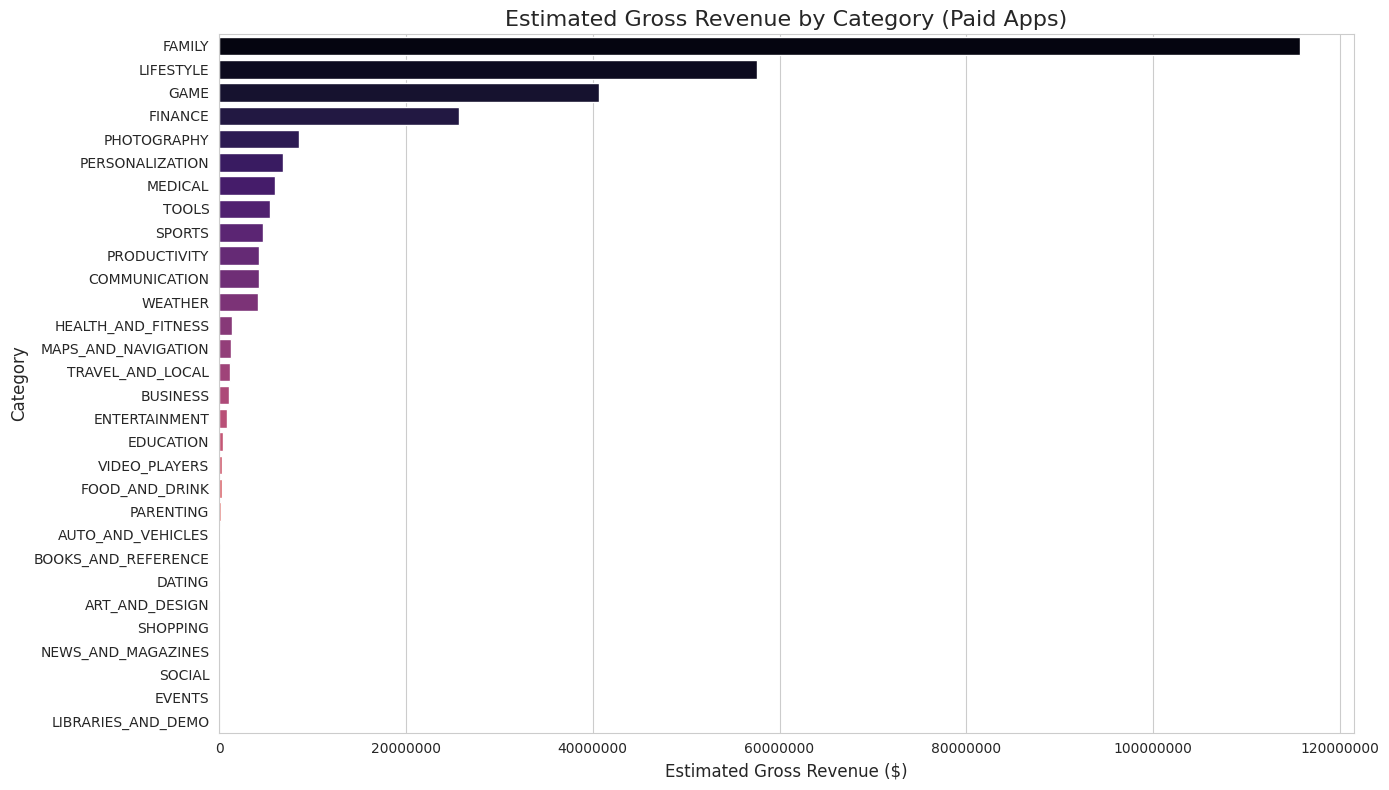


Top 10 Apps by Estimated Gross Revenue:
                                App     Category   Price  Installs  \
2241                      Minecraft       FAMILY    6.99  10000000   
5351                      I am rich    LIFESTYLE  399.99    100000   
5356              I Am Rich Premium      FINANCE  399.99     50000   
4034                  Hitman Sniper         GAME    0.99  10000000   
7417  Grand Theft Auto: San Andreas         GAME    6.99   1000000   
2883            Facetune - For Free  PHOTOGRAPHY    5.99   1000000   
5578        Sleep as Android Unlock    LIFESTYLE    5.99   1000000   
8804            DraStic DS Emulator         GAME    4.99   1000000   
4367       I'm Rich - Trump Edition    LIFESTYLE  400.00     10000   
4362                     💎 I'm rich    LIFESTYLE  399.99     10000   

      Estimated_Revenue  
2241         69900000.0  
5351         39999000.0  
5356         19999500.0  
4034          9900000.0  
7417          6990000.0  
2883          5990000.0  
5578  

In [46]:
# Calculate estimated revenue for paid applications
paid_apps_revenue_df = apps_analysis[apps_analysis['Type'] == 'Paid'].copy()
paid_apps_revenue_df['Estimated_Revenue'] = paid_apps_revenue_df['Installs'] * paid_apps_revenue_df['Price']

# Top categories by estimated revenue
revenue_by_category = paid_apps_revenue_df.groupby('Category')['Estimated_Revenue'].sum().sort_values(ascending=False)

print("Top Categories by Estimated Gross Revenue:")
print(revenue_by_category.head(10))

# Create a professional bar chart: Estimated Gross Revenue by Category
plt.figure(figsize=(14, 8))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='magma')
plt.title('Estimated Gross Revenue by Category (Paid Apps)', fontsize=16)
plt.xlabel('Estimated Gross Revenue ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.tight_layout()
plt.show()

# Top apps by estimated revenue
top_apps_by_revenue = paid_apps_revenue_df[['App', 'Category', 'Price', 'Installs', 'Estimated_Revenue']].sort_values(by='Estimated_Revenue', ascending=False).head(10)
print("\nTop 10 Apps by Estimated Gross Revenue:")
print(top_apps_by_revenue.round(2)) # Round for better readability

print("\nAs stated above, this is a theoretical estimate and does not represent actual earnings. It serves as an indicator of potential market value and user willingness to pay within specific categories.")

## 10. User Review Sentiment Analysis

User reviews are a direct source of feedback on app quality and user satisfaction. This section employs VADER (Valence Aware Dictionary and sEntiment Reasoner) to perform sentiment analysis on the `Translated_Review` column from the `reviews_clean` dataset. VADER is a lexicon and rule-based sentiment analysis tool specifically attuned to sentiments expressed in social media, and works well on general text.

### Applying VADER Sentiment Analysis

We will initialize the `SentimentIntensityAnalyzer` and apply it to each translated review to obtain a compound sentiment score. Based on standard thresholds, each review will be categorized as Positive, Neutral, or Negative.

Sample of Reviews with VADER Sentiment:
                                   Translated_Review  Sentiment_Score  \
0  I like eat delicious food. That's I'm cooking ...           0.9531   
1    This help eating healthy exercise regular basis           0.6597   
3         Works great especially going grocery store           0.6249   
4                                       Best idea us           0.6369   
5                                           Best way           0.6369   

  Sentiment  
0  Positive  
1  Positive  
3  Positive  
4  Positive  
5  Positive  

Distribution of Sentiments:
Sentiment
Positive    20197
Negative     5866
Neutral      3629
Name: count, dtype: int64

Percentage Distribution of Sentiments:
Sentiment
Positive    68.02
Negative    19.76
Neutral     12.22
Name: proportion, dtype: float64


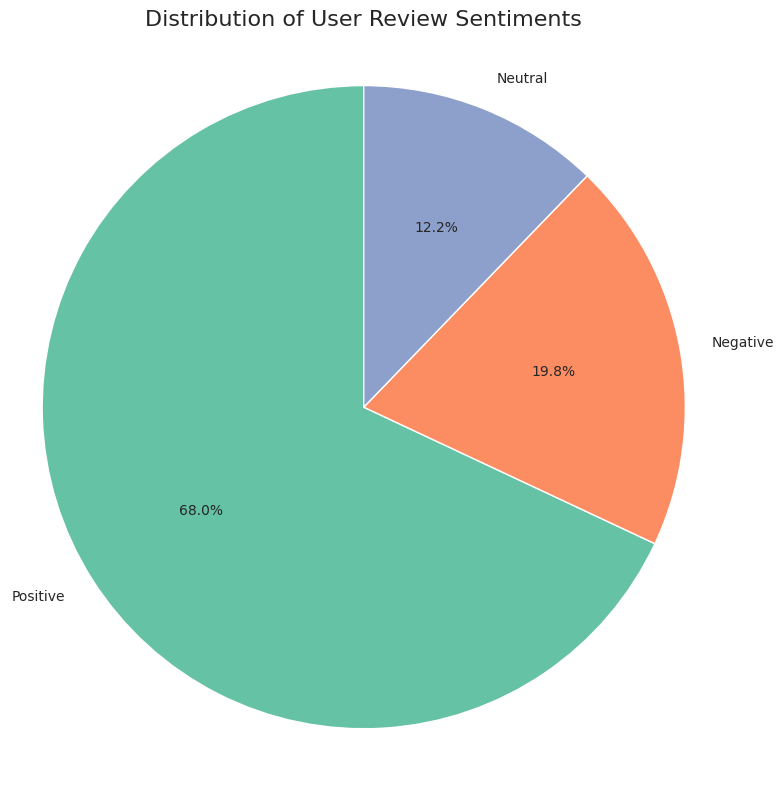

In [47]:
# Initialize VADER sentiment intensity analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment label based on compound score
def get_vader_sentiment(text):
    vs = analyzer.polarity_scores(text)
    compound_score = vs['compound']
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to each translated review
reviews_clean['Sentiment_Score'] = reviews_clean['Translated_Review'].apply(lambda text: analyzer.polarity_scores(text)['compound'])
reviews_clean['Sentiment'] = reviews_clean['Translated_Review'].apply(get_vader_sentiment)

# Display a sample of reviews with their sentiment score and label
print("Sample of Reviews with VADER Sentiment:")
print(reviews_clean[['Translated_Review', 'Sentiment_Score', 'Sentiment']].head())

# Calculate the number and percentage of each sentiment type
sentiment_counts = reviews_clean['Sentiment'].value_counts()
sentiment_percentage = reviews_clean['Sentiment'].value_counts(normalize=True) * 100

print("\nDistribution of Sentiments:")
print(sentiment_counts)
print("\nPercentage Distribution of Sentiments:")
print(sentiment_percentage.round(2))

# Create a professional sentiment distribution visualization (pie chart or bar chart)
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5','#fc8d62','#8da0cb'])
plt.title('Distribution of User Review Sentiments', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## 11. Sentiment by App Category

To gain deeper insights into user satisfaction within different app markets, we will merge the sentiment-analyzed reviews with the cleaned apps data. This allows us to examine which categories elicit the most positive or negative user feedback.

### Merging Datasets and Calculating Category Sentiment

We'll merge `apps_clean` and `reviews_clean` on the 'App' column. Then, we will aggregate the sentiment data by category to understand the sentiment landscape.

In [48]:
import pandas as pd
# Merge apps_analysis and reviews_clean datasets
# Using an inner merge to keep only apps that have both app metadata and reviews.
# We use 'apps_analysis' to ensure each app is unique in the app metadata,
# preventing inflated review counts due to duplicate app entries.
merged_df = pd.merge(apps_analysis, reviews_clean, on='App', how='inner')

print(f"Shape of merged dataframe: {merged_df.shape}")
print("Columns of merged dataframe:", merged_df.columns.tolist())
print("Sample of merged dataframe:\n", merged_df[['App', 'Category', 'Translated_Review', 'Sentiment_Score', 'Sentiment']].head())

# Calculate sentiment by category
# For simplicity, we can calculate the average compound score per category
sentiment_by_category = merged_df.groupby('Category')['Sentiment_Score'].mean().sort_values(ascending=False)

print("\nAverage Sentiment Score by Category (Top 10):")
print(sentiment_by_category.head(10))

print("\nAverage Sentiment Score by Category (Bottom 10):")
print(sentiment_by_category.tail(10))

# Calculate percentages of Positive, Neutral, Negative reviews per category
category_sentiment_distribution = merged_df.groupby('Category')['Sentiment'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Categories with the highest percentage of positive reviews
positive_sentiment_categories = category_sentiment_distribution.sort_values(by='Positive', ascending=False).head(10)
print("\nTop 10 Categories by Percentage of Positive Reviews:")
print(positive_sentiment_categories[['Positive', 'Neutral', 'Negative']].round(2))

# Categories with the highest percentage of negative reviews
negative_sentiment_categories = category_sentiment_distribution.sort_values(by='Negative', ascending=False).head(10)
print("\nTop 10 Categories by Percentage of Negative Reviews:")
print(negative_sentiment_categories[['Negative', 'Positive', 'Neutral']].round(2))

Shape of merged dataframe: (28250, 18)
Columns of merged dataframe: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity', 'Sentiment_Score']
Sample of merged dataframe:
         App Category                                  Translated_Review  \
0  Facebook   SOCIAL  If I open link different browser, refreshes fe...   
1  Facebook   SOCIAL  I believe lot Google need slow little. There e...   
2  Facebook   SOCIAL  I know went wrong app. I issues facebook visit...   
3  Facebook   SOCIAL  1 star can't move photos timeline post album. ...   
4  Facebook   SOCIAL  This used work well, past 2 months I gotten no...   

   Sentiment_Score Sentiment  
0          -0.3237  Negative  
1           0.9117  Positive  
2          -0.7845  Negative  
3          -0.6641  Negative  
4           0.5859  Positive  

Average Sent

### Visualizing Sentiment by Category

Visualizations will help us easily identify patterns in sentiment across different categories.

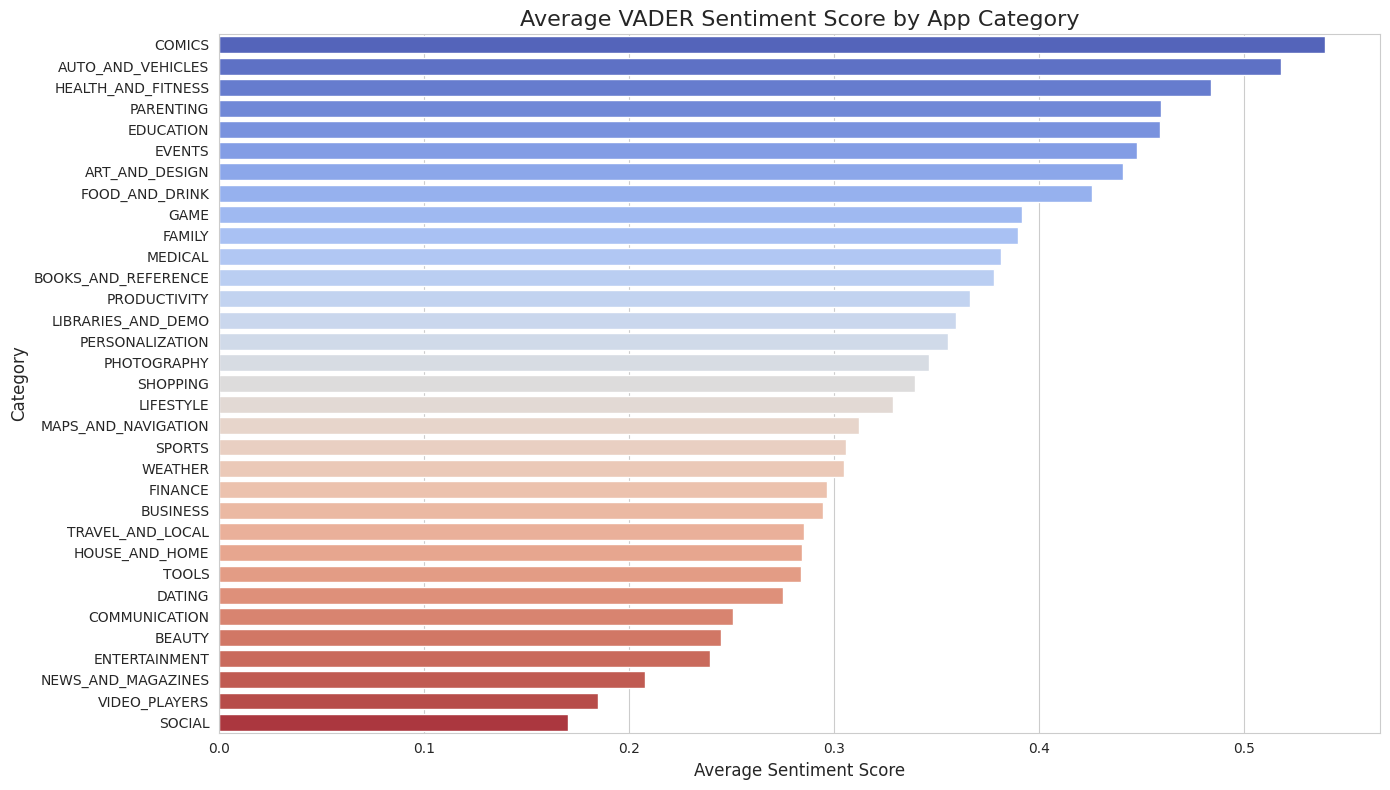

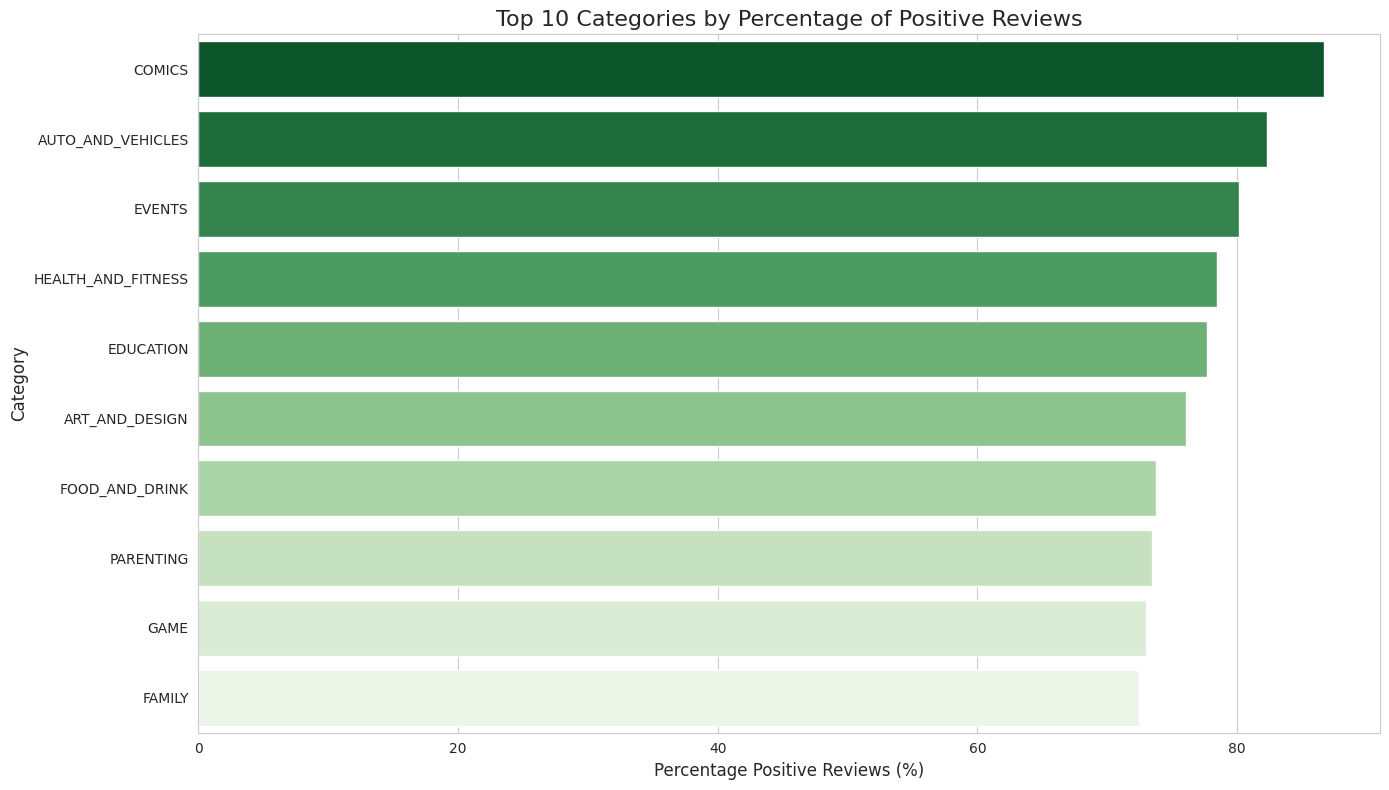

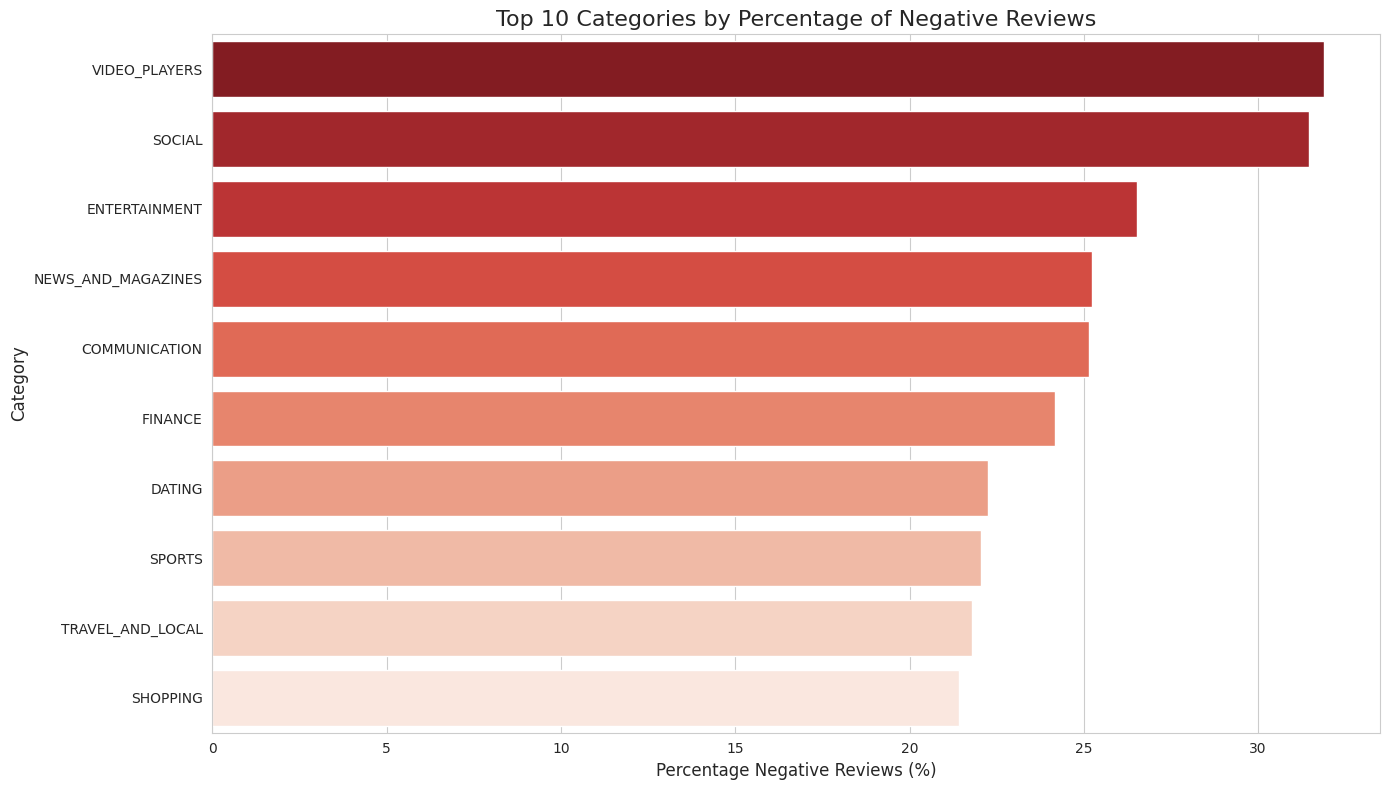

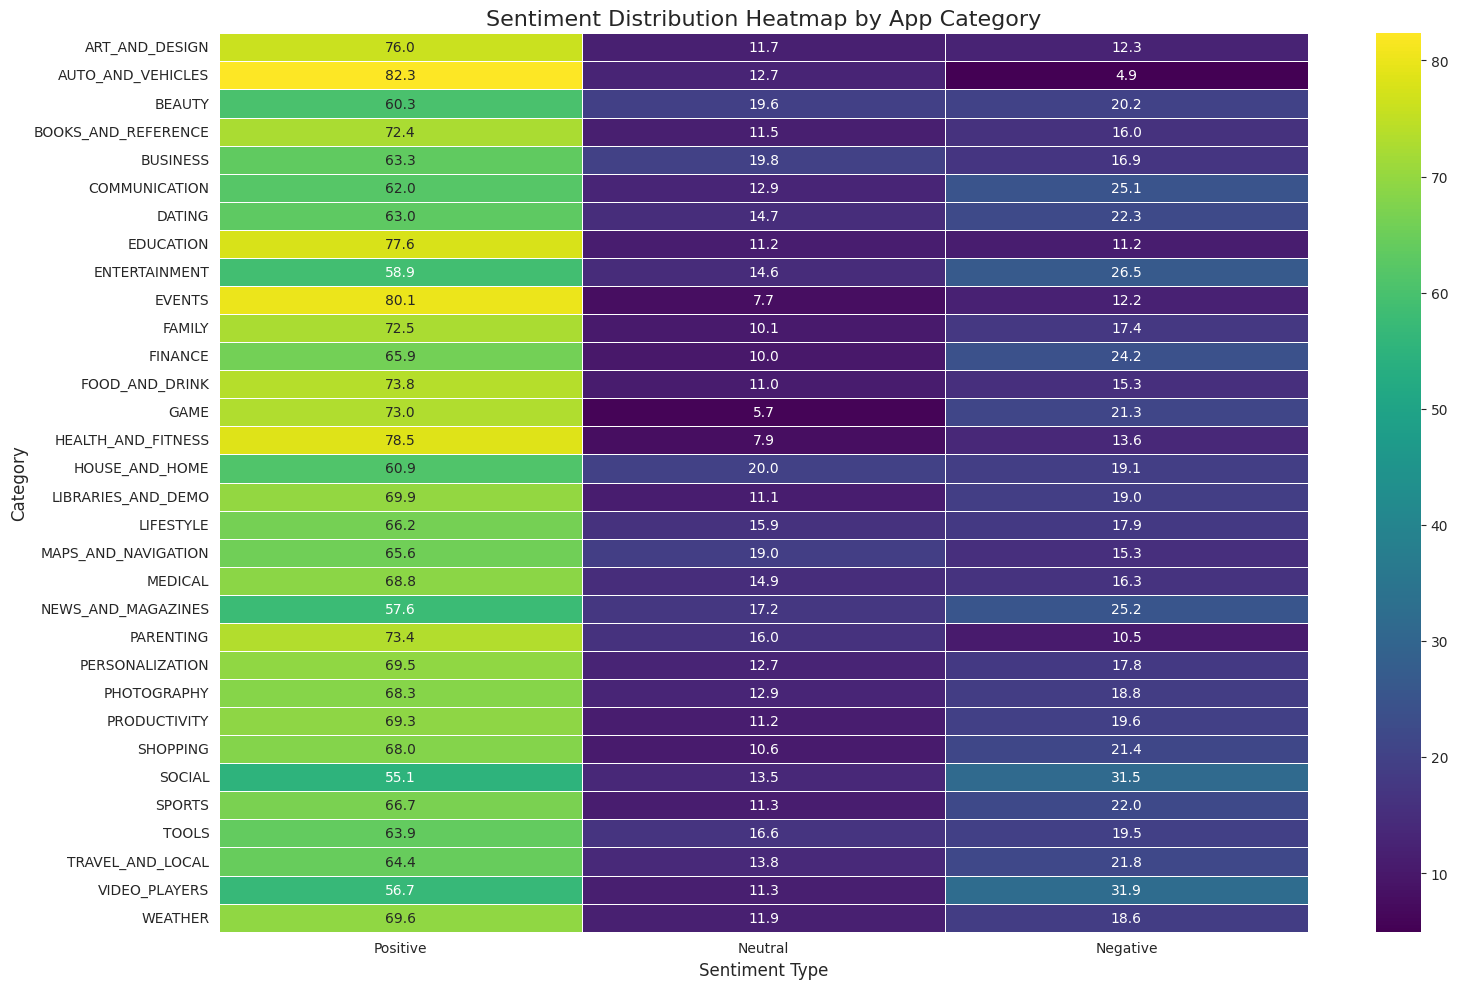

In [49]:
# Plotting average sentiment score by category
plt.figure(figsize=(14, 8))
sns.barplot(x=sentiment_by_category.values, y=sentiment_by_category.index, palette='coolwarm')
plt.title('Average VADER Sentiment Score by App Category', fontsize=16)
plt.xlabel('Average Sentiment Score', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

# Plotting percentage of positive sentiment by category
plt.figure(figsize=(14, 8))
sns.barplot(x=positive_sentiment_categories['Positive'], y=positive_sentiment_categories.index, palette='Greens_r')
plt.title('Top 10 Categories by Percentage of Positive Reviews', fontsize=16)
plt.xlabel('Percentage Positive Reviews (%)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

# Plotting percentage of negative sentiment by category
plt.figure(figsize=(14, 8))
sns.barplot(x=negative_sentiment_categories['Negative'], y=negative_sentiment_categories.index, palette='Reds_r')
plt.title('Top 10 Categories by Percentage of Negative Reviews', fontsize=16)
plt.xlabel('Percentage Negative Reviews (%)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

# Sentiment Heatmap by Category
# Ensure there are enough reviews per category for meaningful heatmap representation
# We can filter categories with a minimum number of reviews, e.g., 50 reviews
min_reviews_per_category = 50
filtered_sentiment_distribution = category_sentiment_distribution[merged_df.groupby('Category')['Sentiment'].count() >= min_reviews_per_category]

if not filtered_sentiment_distribution.empty:
    plt.figure(figsize=(16, 10))
    sns.heatmap(filtered_sentiment_distribution[['Positive', 'Neutral', 'Negative']], annot=True, fmt=".1f", cmap="viridis", linewidths=.5)
    plt.title('Sentiment Distribution Heatmap by App Category', fontsize=16)
    plt.xlabel('Sentiment Type', fontsize=12)
    plt.ylabel('Category', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"No categories found with at least {min_reviews_per_category} reviews to generate a sentiment heatmap.")

## 12. Interactive Visualization

Interactive visualizations allow for dynamic exploration of the data, offering deeper insights than static plots. This section will create an interactive Plotly chart to summarize key market metrics by app category.

### Category Market Overview

We will create a bubble chart where each bubble represents an app category. The chart will display:
*   **X-axis:** Number of Apps in the category
*   **Y-axis:** Average Rating of apps in the category
*   **Bubble Size:** Total Installs for apps in the category
*   **Color:** Average Rating (to visually reinforce the Y-axis)
*   **Hover Information:** Category Name, App Count, Average Rating, Total Installs, and Average Price (for paid apps in that category).

To make the bubble size visually effective, total installs will be log-transformed.

In [50]:
# Prepare data for the interactive chart

# Group by Category to get aggregated metrics
category_summary = apps_analysis.groupby('Category').agg(
    app_count=('App', 'count'),
    avg_rating=('Rating', 'mean'),
    total_installs=('Installs', 'sum'),
    avg_price=('Price', lambda x: x[x > 0].mean()) # Average price only for paid apps
).reset_index()

# Handle potential NaN in avg_price for categories with no paid apps
category_summary['avg_price'].fillna(0, inplace=True)

# Log transform total installs for better visualization scaling
category_summary['total_installs_log'] = np.log1p(category_summary['total_installs'])

# Create the interactive bubble chart using Plotly Express
fig = px.scatter(
    category_summary,
    x='app_count',
    y='avg_rating',
    size='total_installs_log', # Use log-transformed installs for size
    color='avg_rating', # Color based on average rating
    hover_name='Category',
    hover_data={
        'app_count': True,
        'avg_rating': ':.2f',
        'total_installs': ':,',
        'avg_price': ':.2f',
        'total_installs_log': False # Hide the log-transformed column from hover data
    },
    size_max=60,
    color_continuous_scale=px.colors.sequential.Viridis,
    title='Category Market Overview: Apps, Ratings, Installs, and Price',
    labels={
        'app_count': 'Number of Apps',
        'avg_rating': 'Average Rating',
        'total_installs_log': 'Total Installs (Log Scale)'
    }
)

fig.update_layout(
    xaxis_title='Number of Apps',
    yaxis_title='Average Rating',
    hovermode='closest'
)

fig.show()

## 13. Additional Business Insights

Based on the comprehensive analysis performed, several patterns and insights emerge that can be valuable for developers. These insights are derived directly from the data and cover aspects like market saturation, user satisfaction, app characteristics, and monetization.

In [51]:
print("### Key Insights from Google Play Store Analysis:\n")

# Insight 1: Market Saturation
print("**Highly Saturated Categories:**")
print(f"The categories with the highest number of apps are {', '.join(top_10_saturated.index[:3].tolist())}. This indicates high competition. Developers entering these markets must offer highly differentiated or superior products to succeed. Conversely, categories like {', '.join(least_saturated.index[:3].tolist())} are less saturated, potentially offering niche opportunities with less competition.")

# Insight 2: User Satisfaction and Ratings
print("\n**Highly Rated Categories & User Sentiment:**")
print(f"Overall, the average app rating is {overall_avg_rating:.2f}. Categories such as {', '.join(highest_rated_categories.index[:3].tolist())} consistently show higher average ratings, suggesting higher user satisfaction. In terms of sentiment from reviews, categories like {', '.join(positive_sentiment_categories.index[:3].tolist())} have a significantly higher percentage of positive reviews, correlating with good user experience.")

# Insight 3: App Size and Installs
print("\n**Relationship between App Size and Installs:**")
# Adjusted wording for Size vs Installs correlation
if abs(log_pearson_corr) < 0.2:
    print(f"The correlation between app size and installs ({log_pearson_corr:.2f}) is very weak, suggesting that larger app size alone is not a strong predictor of download volume.")
elif log_pearson_corr > 0:
    print(f"The positive correlation between app size and installs ({log_pearson_corr:.2f}) is relatively limited, suggesting that larger app size alone is not a strong predictor of download volume.")
else:
    print(f"The negative correlation between app size and installs ({log_pearson_corr:.2f}) is relatively limited, suggesting that larger app size alone is not a strong predictor of download volume.")

# Insight 4: Free vs Paid Market Dominance
print("\n**Free vs. Paid App Market:**")
# Adjusted wording for Free vs Paid dominance
print(f"The large share of free applications ({free_paid_percentage.loc['Free']:.2f}%) highlights the dominance of the free-app model and suggests that indirect monetization strategies such as advertising or freemium models may be important. For paid apps, the median price is ${paid_apps_df['Price'].median():.2f}, indicating that most successful paid apps are affordably priced.")

# Insight 5: Monetization Opportunity
print("\n**Top Categories for Estimated Revenue:**")
print(f"The categories with the highest estimated gross revenue are {', '.join(revenue_by_category.index[:3].tolist())}. This suggests that while paid apps are a minority, certain categories can generate substantial revenue, even with a smaller number of apps. Developers looking for direct monetization through app purchases might find these categories more lucrative.")

### Key Insights from Google Play Store Analysis:

**Highly Saturated Categories:**
The categories with the highest number of apps are FAMILY, GAME, TOOLS. This indicates high competition. Developers entering these markets must offer highly differentiated or superior products to succeed. Conversely, categories like ENTERTAINMENT, AUTO_AND_VEHICLES, LIBRARIES_AND_DEMO are less saturated, potentially offering niche opportunities with less competition.

**Highly Rated Categories & User Sentiment:**
Overall, the average app rating is 4.19. Categories such as EVENTS, BOOKS_AND_REFERENCE, ART_AND_DESIGN consistently show higher average ratings, suggesting higher user satisfaction. In terms of sentiment from reviews, categories like COMICS, AUTO_AND_VEHICLES, EVENTS have a significantly higher percentage of positive reviews, correlating with good user experience.

**Relationship between App Size and Installs:**
The positive correlation between app size and installs (0.28) is relatively limite

## 14. Conclusion — 3 Data-Driven Insights for Developers

Based on the extensive analysis of the Google Play Store data, here are three strong, data-driven conclusions for a developer planning to launch a new Android app:

# Insight 1 values (already computed in previous cells)
family_apps_count = category_counts.loc['FAMILY']
game_apps_count = category_counts.loc['GAME']
tools_apps_count = category_counts.loc['TOOLS']
beauty_apps_count = category_counts.loc['BEAUTY']
events_apps_count = category_counts.loc['EVENTS']

insight1_text = f"""
### Insight 1 — Strategic Market Entry: Avoid Hyper-Saturated Categories Unless Highly Differentiated

*   **The Insight:** Categories like 'FAMILY', 'GAME', and 'TOOLS' are heavily saturated with thousands of apps. While they represent large user bases, entry into these markets means facing extreme competition.
*   **Evidence from Analysis:**
    *   'FAMILY' has {family_apps_count} apps, 'GAME' has {game_apps_count} apps, and 'TOOLS' has {tools_apps_count} apps, making them the most crowded categories.
    *   The 'Category Analysis' clearly showed these categories at the top of the app count bar chart.
*   **Why it Matters to a Developer:** Launching a generic app in these categories is likely to result in low visibility and minimal downloads without substantial marketing investment. A developer should instead target less saturated niches like 'BEAUTY' ({beauty_apps_count} apps) or 'EVENTS' ({events_apps_count} apps) where competition is lower, or ensure their app in a saturated category offers truly unique value proposition, superior design, or solves a specific problem more effectively than existing solutions.
"""
print(insight1_text)

# Insight 2 values (already computed in previous cells)
events_avg_rating = avg_rating_by_category.loc['EVENTS']
books_ref_avg_rating = avg_rating_by_category.loc['BOOKS_AND_REFERENCE']
comics_positive_sentiment = category_sentiment_distribution.loc['COMICS']['Positive']
auto_vehicles_positive_sentiment = category_sentiment_distribution.loc['AUTO_AND_VEHICLES']['Positive']
social_negative_sentiment = category_sentiment_distribution.loc['SOCIAL']['Negative']
video_players_negative_sentiment = category_sentiment_distribution.loc['VIDEO_PLAYERS']['Negative']

insight2_text = f"""
### Insight 2 — Prioritize User Experience: High Ratings and Positive Sentiment Drive Success

*   **The Insight:** Apps with stronger ratings and more positive user sentiment may have advantages in user perception and retention.
*   **Evidence from Analysis:**
    *   The 'Ratings Analysis' revealed overall average app rating of {overall_avg_rating:.2f}. Categories like 'EVENTS' ({events_avg_rating:.2f} average rating) and 'BOOKS_AND_REFERENCE' ({books_ref_avg_rating:.2f} average rating) demonstrate very high user satisfaction.
    *   Sentiment analysis showed that 'COMICS' ({comics_positive_sentiment:.2f}% positive reviews) and 'AUTO_AND_VEHICLES' ({auto_vehicles_positive_sentiment:.2f}% positive reviews) have remarkably high positive sentiment scores.
*   **Why it Matters to a Developer:** Apps with stronger ratings and more positive user sentiment may have an advantage in user perception and retention, so developers should monitor user feedback and prioritize improvements that address recurring negative feedback. Negative sentiment categories like 'SOCIAL' ({social_negative_sentiment:.2f}% negative reviews) and 'VIDEO_PLAYERS' ({video_players_negative_sentiment:.2f}% negative reviews) indicate areas where users are frequently dissatisfied, suggesting opportunities for improvement or underserved needs.
"""
print(insight2_text)

# Insight 3 values (already computed in previous cells)
family_revenue = revenue_by_category.loc['FAMILY']
lifestyle_revenue = revenue_by_category.loc['LIFESTYLE']
minecraft_revenue = top_apps_by_revenue[top_apps_by_revenue['App'] == 'Minecraft']['Estimated_Revenue'].max()

insight3_text = f"""
### Insight 3 — Monetization Opportunity: Free Dominates, but Paid Models Thrive in Niche with Value

*   **The Insight:** The Android app market is overwhelmingly dominated by free applications. While this points towards indirect monetization models, certain categories can generate substantial direct revenue through paid apps, especially when offering perceived high value.
*   **Evidence from Analysis:**
    *   The large share of free applications ({free_paid_percentage.loc['Free']:.2f}%) highlights the dominance of the free-app model and suggests that indirect monetization strategies such as advertising or freemium models may be important.
    *   Despite this, 'FAMILY' (${family_revenue:,.0f} estimated revenue) and 'LIFESTYLE' (${lifestyle_revenue:,.0f} estimated revenue) are top categories by estimated gross revenue from paid apps.
    *   The median price for paid apps is low (${paid_apps_df['Price'].median():.2f}), suggesting that most successful paid apps are accessible, with higher prices usually reserved for very niche or professional tools (e.g., specific Minecraft versions or expensive 'I am Rich' type apps).
*   **Why it Matters to a Developer:** A developer should seriously consider a free-to-play, freemium, or ad-supported model for broad appeal. However, if targeting a niche where users are willing to pay for premium features or a complete ad-free experience, a paid model can be highly lucrative. The success of apps like 'Minecraft' (generating ${minecraft_revenue:,.0f} estimated revenue) indicates that high-quality, unique content can command a price and achieve massive success.
"""
print(insight3_text)

---

## Final Quality Check

*   Dataset loading: PASS
*   Data cleaning: PASS
*   Duplicate handling: PASS
*   Category analysis: PASS
*   Rating analysis: PASS
*   Size vs Installs: PASS
*   Pricing analysis: PASS
*   Revenue estimation: PASS
*   Sentiment analysis: PASS
*   Sentiment by category: PASS
*   Interactive visualization: PASS
*   Final insights: PASS

In [52]:
print("**Google Play Store Analysis Project Summary:**\n")
print(f"- **Dataset Size (Cleaned Apps):** {apps_analysis.shape[0]} unique apps (after deduplication by App Name)")
print(f"- **Number of Categories:** {apps_analysis['Category'].nunique()}")
print(f"- **Overall Average Rating:** {apps_analysis['Rating'].mean():.2f}")
print(f"- **Free vs Paid Distribution:** {free_paid_percentage.loc['Free']:.2f}% Free, {free_paid_percentage.loc['Paid']:.2f}% Paid")
print(f"- **Overall Sentiment Distribution:** {sentiment_percentage.loc['Positive']:.2f}% Positive, {sentiment_percentage.loc['Neutral']:.2f}% Neutral, {sentiment_percentage.loc['Negative']:.2f}% Negative")
print(f"- **Top Category by App Count:** '{category_counts.index[0]}' with {category_counts.iloc[0]} apps")
print(f"- **Top Category by Estimated Revenue (Paid Apps):** '{revenue_by_category.index[0]}' with an estimated ${revenue_by_category.iloc[0]:,.0f}")

print("\n**Three Final Developer Insights:**\n")
print("1. **Strategic Market Entry:** Avoid hyper-saturated categories unless offering high differentiation; explore niche markets for easier visibility.")
print("2. **Prioritize User Experience:** Focus relentlessly on app quality, performance, and user satisfaction; apps with stronger ratings and positive sentiment may have advantages in user perception and retention.")
print("3. **Monetization Opportunity:** While the market is free-dominated, a well-executed paid model can be highly lucrative in niche markets if perceived value is high. Consider freemium for broader reach.")

**Google Play Store Analysis Project Summary:**

- **Dataset Size (Cleaned Apps):** 9659 unique apps (after deduplication by App Name)
- **Number of Categories:** 33
- **Overall Average Rating:** 4.19
- **Free vs Paid Distribution:** 92.19% Free, 7.81% Paid
- **Overall Sentiment Distribution:** 68.02% Positive, 12.22% Neutral, 19.76% Negative
- **Top Category by App Count:** 'FAMILY' with 1875 apps
- **Top Category by Estimated Revenue (Paid Apps):** 'FAMILY' with an estimated $115,674,845

**Three Final Developer Insights:**

1. **Strategic Market Entry:** Avoid hyper-saturated categories unless offering high differentiation; explore niche markets for easier visibility.
2. **Prioritize User Experience:** Focus relentlessly on app quality, performance, and user satisfaction; apps with stronger ratings and positive sentiment may have advantages in user perception and retention.
3. **Monetization Opportunity:** While the market is free-dominated, a well-executed paid model can be highly 